# 🤖 Notebook 10 — KI-Agenten in der Ermittlungspraxis

**KI Advanced · IA1017000 · Polizei Baden-Württemberg · Institut für Fortbildung**

---

| | |
|---|---|
| **Session** | S 3.2 – KI-Agenten & Agentenframeworks |
| **Niveau** | Einsteiger — kein Programmierwissen erforderlich |
| **Dauer** | ca. 45 Minuten |
| **Datenbasis** | [github.com/mb4n6/cryptotrust](https://github.com/mb4n6/cryptotrust) |

---

## 🚔 Der Fall: CEO-Fraud mit Deepfake — AZ 2026-KK-00471

Ein Buchhalter der DataTrust GmbH Stuttgart erhält einen Teams-Videoanruf vom
vermeintlichen Geschäftsführer — generiert mit KI. Er überweist 122.150 EUR
an die Baltic Trade LLC. Das Geld ist weg. Die Polizei Stuttgart ermittelt.

**Dieses Notebook zeigt:** Wie ein KI-Agent diese Akte automatisch analysiert —
von der ersten IBAN-Prüfung bis zum forensischen Abschlussbericht.

---

## 📍 Wo läuft dieses Notebook?

| Umgebung | LLM | Voraussetzung |
|----------|-----|---------------|
| **Seminarraum** | Ollama lokal (llama3.1:8b) | Ollama + Modell geladen |
| **Google Colab / Zuhause** | Groq API (llama-3.1-8b-instant) | Kostenloser API-Key |

Das Notebook **erkennt die Umgebung automatisch** — kein manuelles Umschalten.

---

## 🔑 Groq API-Key (nur außerhalb des Seminarraums)

**1.** Account auf [console.groq.com](https://console.groq.com) erstellen (kostenlos, 2 Min.)

**2.** API Keys → Create API key → Key kopieren (beginnt mit `gsk_`)

**3.** Key sicher eintragen — **niemals in Code-Zellen speichern:**
```
Colab:  Schloss-Symbol links → Secrets → GROQ_API_KEY
Lokal:  Direkte Eingabe wenn gefragt (wird nicht gespeichert)
```

---

## 🗺️ Ablauf

```
Zelle A  │ Setup & LLM          Umgebung erkennen, Verbindung herstellen
Zelle B  │ Datenbasis           Fallakte von GitHub laden
─────────┼──────────────────────────────────────────────────────────
Schritt 1 │ ReAct-Prinzip        Wie ein Agent denkt — live an der Akte
Schritt 2 │ Tools               Vier Werkzeuge für die Fallanalyse
Schritt 3 │ Mini-Agent          Automatische ReAct-Schleife — regelbasiert
Schritt 4 │ Multi-Agent         Tech-, Legal- und Report-Agent kooperieren
Schritt 5 │ Echter LLM-Agent    LangChain + Ollama/Groq — freies Reasoning
Schritt 6 │ Challenge           Vollanalyse + automatischer Ermittlungsbericht
```

> ⚖️ Alle Personen, Firmen und Transaktionen sind **fiktiv** (Ausbildungszweck).


---

## ⚙️ Zelle A — Setup & LLM-Verbindung

**Was passiert hier?**

Diese Zelle erledigt alles Technische bevor wir mit dem Fall anfangen:
- Installiert fehlende Python-Pakete (in Colab automatisch, lokal meist vorhanden)
- Erkennt ob wir im Seminarraum (Ollama) oder in Colab (Groq) arbeiten
- Fragt den Groq API-Key ab wenn nötig
- Stellt die LLM-Verbindung her und speichert sie in der Variable `llm`

**Das Ergebnis dieser Zelle** — die Variable `llm` — wird in Schritt 5 verwendet.
Alle Schritte davor (1–4) brauchen kein LLM und laufen immer.

> ▶️ **Jetzt ausführen:** `Shift + Enter`


In [1]:
# ════════════════════════════════════════════════════════════
# ZELLE A — Setup, Umgebungserkennung & LLM-Verbindung
# ════════════════════════════════════════════════════════════

import sys, os, subprocess, urllib.request, json as _json, getpass, warnings
from typing import Optional

warnings.filterwarnings('ignore')

# ── 1. Sind wir in Google Colab? ─────────────────────────────
# Colab hat kein Ollama — dort nutzen wir die Groq API.
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Umgebung erkannt: {'Google Colab' if IN_COLAB else 'Lokal (Jupyter / VS Code)'}")
print()

# ── 2. Pakete installieren ────────────────────────────────────
# Alle LangChain-Pakete — in Colab fehlen sie, lokal meist vorhanden.
PAKETE = ["langchain-core", "langchain-community", "langgraph",
          "langchain-ollama", "langchain-groq", "matplotlib"]

print("Pakete prüfen...")
fehlende = []
for p in PAKETE:
    try:
        __import__(p.replace("-","_"))
    except ImportError:
        fehlende.append(p)

if fehlende:
    print(f"  Installiere: {', '.join(fehlende)}")
    subprocess.run([sys.executable,"-m","pip","install",*fehlende,"-q"],
                   capture_output=True)
print(f"✅ Pakete bereit ({len(PAKETE)} gesamt)")
print()

# ── 3. Importe ────────────────────────────────────────────────
import matplotlib.pyplot as plt
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage
from langgraph.prebuilt import create_react_agent

# Grafik-Stil (Polizei BW Farbpalette)
C = {'navy':'#001E46','blue1':'#0D3761','blue2':'#1A4E8A','ice':'#4FC3F7',
     'orange':'#ED7D31','green':'#52B788','teal':'#00B4D8','lgray':'#B0C4DE',
     'white':'#FFFFFF','purple':'#9B59B6','gold':'#FFC300','red':'#E74C3C'}
plt.style.use('dark_background')
plt.rcParams.update({'figure.facecolor':C['navy'],'axes.facecolor':C['blue1'],
    'axes.edgecolor':C['lgray'],'axes.labelcolor':C['lgray'],
    'xtick.color':C['lgray'],'ytick.color':C['lgray'],
    'text.color':C['white'],'grid.color':C['blue2'],'grid.alpha':0.4,'font.size':11})

print("✅ Bibliotheken geladen")
print()

# ── 4. LLM-Verbindung ────────────────────────────────────────
# Wir prüfen drei Optionen der Reihe nach.

def _ollama_aktiv(model="llama3.1:8b") -> bool:
    """Prüft ob Ollama lokal läuft und das Modell geladen ist."""
    try:
        r = urllib.request.urlopen('http://localhost:11434/api/tags', timeout=2)
        modelle = [m['name'] for m in _json.loads(r.read())['models']]
        return any(model.split(':')[0] in m for m in modelle)
    except: return False

def _groq_key() -> Optional[str]:
    """Sucht Groq-Key: Colab Secrets → Umgebungsvariable → Interaktiv."""
    # Colab Secrets
    if IN_COLAB:
        try:
            from google.colab import userdata
            k = userdata.get('GROQ_API_KEY')
            if k: print("  Key gefunden: Colab Secrets"); return k
        except: pass
    # Umgebungsvariable
    k = os.environ.get('GROQ_API_KEY','').strip()
    if k: print("  Key gefunden: Umgebungsvariable"); return k
    # Interaktive Eingabe
    print()
    print("  ┌──────────────────────────────────────────────────────┐")
    print("  │  Groq API-Key eingeben (console.groq.com → API Keys) │")
    print("  │  Der Key wird NICHT gespeichert.                     │")
    print("  └──────────────────────────────────────────────────────┘")
    try:
        k = getpass.getpass("  gsk_... : ").strip()
        if k: print("  Key eingegeben ✅"); return k
    except: pass
    return None

# Globale LLM-Variablen (von Schritt 5 verwendet)
llm, llm_name, llm_aktiv = None, "–", False

print("LLM-Verbindung wird hergestellt...")
print()

if _ollama_aktiv():
    # Option 1: Ollama lokal — beste Wahl im Seminarraum
    from langchain_ollama import ChatOllama
    llm = ChatOllama(model="llama3.1:8b",base_url="http://localhost:11434",temperature=0)
    llm_name, llm_aktiv = "Ollama lokal (llama3.1:8b)", True
    print("✅ Ollama lokal verbunden")
    print("   Modell: llama3.1:8b | Datenschutz: vollständig lokal")
else:
    print("Ollama nicht gefunden → Groq API wird gesucht...")
    k = _groq_key()
    if k:
        try:
            from langchain_groq import ChatGroq
            llm = ChatGroq(model="llama-3.1-8b-instant",api_key=k,temperature=0)
            llm_name, llm_aktiv = "Groq API (llama-3.1-8b-instant)", True
            print()
            print("✅ Groq API verbunden")
            print("   Modell: llama-3.1-8b-instant | ⚠️  US-Cloud, nur für Übungsdaten!")
        except Exception as e:
            print(f"⚠️  Groq-Verbindung fehlgeschlagen: {e}")
    else:
        print("  Kein Key eingegeben.")

if not llm_aktiv:
    print()
    print("ℹ️  Kein LLM verbunden.")
    print("   Schritte 1–4 und 6 laufen vollständig ohne LLM.")
    print("   Schritt 5 zeigt den Ablauf ohne echten LLM-Aufruf.")

print()
print("━" * 48)
print(f"  LLM:      {llm_name}")
print(f"  Umgebung: {'Colab' if IN_COLAB else 'Lokal'}")
print("━" * 48)
print("✅ Setup abgeschlossen")


Umgebung erkannt: Lokal (Jupyter / VS Code)

Pakete prüfen...
  Installiere: langchain-community
✅ Pakete bereit (6 gesamt)

✅ Bibliotheken geladen

LLM-Verbindung wird hergestellt...

Ollama nicht gefunden → Groq API wird gesucht...

  ┌──────────────────────────────────────────────────────┐
  │  Groq API-Key eingeben (console.groq.com → API Keys) │
  │  Der Key wird NICHT gespeichert.                     │
  └──────────────────────────────────────────────────────┘


  gsk_... :  ········


  Key eingegeben ✅

✅ Groq API verbunden
   Modell: llama-3.1-8b-instant | ⚠️  US-Cloud, nur für Übungsdaten!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM:      Groq API (llama-3.1-8b-instant)
  Umgebung: Lokal
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Setup abgeschlossen


---

## 📂 Zelle B — Datenbasis laden

**Was passiert hier?**

Die Fallakte AZ 2026-KK-00471 liegt als strukturierte JSON-Datenbasis auf GitHub:
[github.com/mb4n6/cryptotrust](https://github.com/mb4n6/cryptotrust)

Diese Zelle lädt alle 11 Dateien und stellt sie als Python-Objekte bereit.
Alle Schritte danach arbeiten direkt mit diesen Daten — keine hartcodierten Werte.

| Variable | Inhalt |
|----------|--------|
| `fallakte` | Sachverhalt, Tatbestände, Maßnahmen |
| `transaktionen` | Beide Überweisungen mit SWIFT-Referenzen |
| `personen` | Tatverdächtige, Zeugen, Geschädigte |
| `deepfake` | Forensischer Befund Video-Analyse |
| `emails` | E-Mails mit IP-Header-Analyse |
| `timeline` | Chronologie aller 8 Ereignisse |
| ... | weitere Aktenbestandteile |



In [2]:
# ════════════════════════════════════════════════════════════
# ZELLE B — Datenbasis von GitHub laden
# Quelle: https://github.com/mb4n6/cryptotrust
# ════════════════════════════════════════════════════════════

BASE_URL = "https://raw.githubusercontent.com/mb4n6/cryptotrust/main"

def lade_json(pfad: str) -> dict:
    """Lädt eine JSON-Datei aus dem GitHub-Repository."""
    try:
        with urllib.request.urlopen(f"{BASE_URL}/{pfad}", timeout=10) as r:
            return _json.loads(r.read().decode('utf-8'))
    except Exception as e:
        print(f"  ✗ {pfad}: {e}")
        return {}

print("Lade Fallakte AZ 2026-KK-00471 von github.com/mb4n6/cryptotrust ...")
print()

fallakte      = lade_json("akte/fallakte.json")
timeline      = lade_json("akte/timeline.json")
personen      = lade_json("personen/personen.json")
transaktionen = lade_json("transaktionen/transaktionen.json")
konten        = lade_json("transaktionen/konten.json")
emails        = lade_json("kommunikation/emails.json")
vernehmungen  = lade_json("kommunikation/vernehmungen.json")
beweismittel  = lade_json("beweise/beweismittel.json")
deepfake      = lade_json("beweise/deepfake_befund.json")
baltic_trade  = lade_json("organisation/baltic_trade.json")
recht         = lade_json("rechtlich/tatbestaende.json")

geladen = sum(1 for v in [fallakte,timeline,personen,transaktionen,konten,
                           emails,vernehmungen,beweismittel,deepfake,
                           baltic_trade,recht] if v)
print(f"{'✅' if geladen==11 else '⚠️ '} {geladen}/11 Dateien geladen")
print()

# ── Was steht in der Akte? ────────────────────────────────────
if fallakte:
    sf  = fallakte['sachverhalt']
    ms  = fallakte.get('massnahmen', [])
    tbs = fallakte.get('tatbestaende', [])
    print(f"  Aktenzeichen:  {fallakte['aktenzeichen']}")
    print(f"  Tatmodus:      {sf['tatmodus']}")
    print(f"  Gesamtschaden: {sf['gesamtschaden_eur']:,.2f} EUR")
    print(f"  Tatbestände:   {', '.join(t['paragraph'] for t in tbs)}")
    print(f"  Maßnahmen:     {len(ms)} laufend ({', '.join(m['massnahme'] for m in ms)})")

if personen:
    pl = personen['personen']
    print(f"  Personen:      {len(pl)}")
    for p in pl:
        print(f"    • {p['rolle']:25s} {p.get('vorname','?')} {p['nachname']}")

if transaktionen:
    tx = transaktionen['transaktionen']
    print(f"  Transaktionen: {len(tx)}")
    for t in tx:
        print(f"    • {t['datum']}  {t['betrag_eur']:>10,.2f} EUR  {t['empfaenger']['name']}")

if timeline:
    print(f"  Timeline:      {len(timeline['timeline'])} Ereignisse")

print()
print("✅ Datenbasis bereit")


Lade Fallakte AZ 2026-KK-00471 von github.com/mb4n6/cryptotrust ...

✅ 11/11 Dateien geladen

  Aktenzeichen:  AZ 2026-KK-00471
  Tatmodus:      CEO-Fraud / Business Email Compromise mit Deepfake-Video
  Gesamtschaden: 122,150.00 EUR
  Tatbestände:   § 263 StGB, § 269 StGB, § 263a StGB
  Maßnahmen:     4 laufend (TKÜ, Kontensperre, EU-Rechtshilfe Ukraine, Dinglicher Arrest)
  Personen:      5
    • Tatverdächtiger           Maksym Bondarenko
    • Tatverdächtiger           unbekannt unbekannt
    • Geschädigte / Zeugin      Sandra Auer
    • Zeuge                     Thomas Maier
    • Zeuge / Geschädigter      Dr. Klaus Bergmann
  Transaktionen: 2
    • 2026-01-09   93,400.00 EUR  Baltic Trade LLC
    • 2026-01-15   28,750.00 EUR  Baltic Trade LLC
  Timeline:      8 Ereignisse

✅ Datenbasis bereit


---

## 🧠 Schritt 1 — Das ReAct-Prinzip: Wie ein Agent denkt und handelt

### Was ist ein KI-Agent?

Ein normales LLM beantwortet eine Frage in einem Schritt.
Ein **Agent** arbeitet in einer Schleife: Er denkt, handelt, beobachtet das Ergebnis —
und wiederholt das, bis die Aufgabe erledigt ist.

Das Muster heißt **ReAct** (Reasoning + Acting):

```
  💭 THOUGHT          ⚙️ ACTION            👁️ OBSERVATION
  "Was weiß ich?  →   Werkzeug (Tool)  →   Ergebnis lesen
   Was fehlt?"         aufrufen              und auswerten
        ▲                                        │
        └────────────────────────────────────────┘
                          (Schleife)
                    ↓ wenn Aufgabe erledigt:
                    ✅ ANSWER
```

### Warum ist eine Schleife nötig?

Weil ein Ermittler auch nicht alles auf einmal weiß.
Er liest die Akte → findet eine IBAN → prüft die IBAN → findet einen Namen →
bewertet den Namen → berechnet den Schaden → formuliert den Befund.
Jeder Schritt braucht das Ergebnis des vorherigen.

### Was wir jetzt tun

Wir führen diese Schleife **manuell** aus — Schritt für Schritt sichtbar.
Keine versteckte KI-Logik, nur Python-Code der läuft.
Die Daten kommen direkt aus der GitHub-Datenbasis.


In [3]:
# ════════════════════════════════════════════════════════════
# SCHRITT 1 — ReAct-Ablauf manuell ausgeführt
#
# Wir schreiben jeden Thought-Action-Observation-Schritt
# explizit auf und führen ihn aus.
# Die Daten kommen aus der GitHub-Datenbasis (Zelle B).
# ════════════════════════════════════════════════════════════

# ── Hilfsfunktion: einfache Aktensuche für Schritt 1 ─────────
# (In Schritt 2 bauen wir echte LangChain-Tools daraus)
def suche(kategorie: str) -> str:
    """Sucht einen Begriff in der Fallakte und gibt den Befund zurück."""
    k = kategorie.lower()

    # Transaktionen
    if 'transaktion' in k and transaktionen:
        tx = transaktionen['transaktionen']
        return " | ".join(
            f"{t['datum']} {t['uhrzeit']} · {t['betrag_eur']:,.0f} EUR · "
            f"{t['auftraggeber']['name']} → {t['empfaenger']['name']} · Ref: {t['swift_ref']}"
            for t in tx)

    # IBAN
    if 'iban' in k and konten:
        ko = konten['konten'][0]
        return (f"{ko['iban']} · Inhaber: {ko['inhaber']} · "
                f"Bank: {ko['bank']} · Risiko: {ko['risikostufe']} · "
                f"Status: {ko['konto_status']}")

    # Tatverdächtiger
    if any(x in k for x in ['bondarenko','verdächt','tatverd']) and personen:
        tv2 = next((p for p in personen['personen'] if p.get('kuerzel')=='TV2'), None)
        if tv2:
            return (f"{tv2['vorname']} {tv2['nachname']}, geb. {tv2['geburtsdatum']}, "
                    f"{tv2['staatsangehoerigkeit']} · Funktion: {tv2['funktion']} · "
                    f"Risiko: {tv2['risikostufe']} · Maßnahmen: {', '.join(tv2['massnahmen'])}")

    # Tatbestände
    if any(x in k for x in ['tatbestand','paragraph','stgb']) and fallakte:
        tbs = fallakte['tatbestaende']
        return " | ".join(f"{t['paragraph']} {t['bezeichnung']}: {t['begruendung'][:60]}"
                          for t in tbs)

    # Deepfake
    if 'deepfake' in k and deepfake:
        a = deepfake['analyse']
        return (f"KI-Wahrscheinlichkeit: {a['ki_wahrscheinlichkeit_prozent']}% · "
                f"Tool: {a['tool']} {a['version']} · Befund: {a['befund']}")

    return f"Kein Eintrag für '{kategorie}'"

# ── ReAct-Ablauf ──────────────────────────────────────────────
# Jeder Schritt: erst der Gedanke (Thought), dann die Aktion,
# dann das Ergebnis (Observation). Aus der Datenbasis.

print("REACT-ABLAUF — AZ 2026-KK-00471")
print("=" * 65)
print(f"Aufgabe: Analysiere den Fall und erstelle einen forensischen Befund.")

schritte = [
    # (Thought, Aktion-Text, Funktion/Ergebnis)
    ("Ich starte mit den Transaktionsdaten. Was wurde überwiesen?",
     "suche('transaktion')",
     lambda: suche('transaktion')),

    ("Transaktionen gefunden. Jetzt die Empfänger-IBAN validieren.",
     "suche('iban')",
     lambda: suche('iban')),

    ("IBAN bekannt: Baltic Trade LLC, Hochrisiko. Wer steckt dahinter?",
     "suche('bondarenko')",
     lambda: suche('bondarenko')),

    ("Tatverdächtiger identifiziert. Welche Tatbestände greifen?",
     "suche('tatbestand')",
     lambda: suche('tatbestand')),

    ("Tatbestände klar. Wie gut ist der Deepfake-Beweis?",
     "suche('deepfake')",
     lambda: suche('deepfake')),
]

for i, (thought, action_text, action_fn) in enumerate(schritte, 1):
    print(f"\n[Schritt {i}]")
    print(f"  💭 Thought:     {thought}")
    print(f"  ⚙️  Action:      {action_text}")
    obs = action_fn()
    print(f"  👁️  Observation:")
    # Langer Text: eingerückt umbrechen
    for zeile in obs.split(' | '):
        print(f"              {zeile.strip()}")

# Finale Antwort
schaden = fallakte['sachverhalt']['gesamtschaden_eur'] if fallakte else 122150
tbs     = " + ".join(t['paragraph'] for t in fallakte.get('tatbestaende',[])) if fallakte else "§263+§269"
print(f"\n{'─'*65}")
print(f"✅ ANSWER:")
print(f"   Gesamtschaden:   {schaden:,.0f} EUR (zwei Transaktionen, Jan 2026)")
print(f"   Empfänger:       Baltic Trade LLC → HOCHRISIKO (Bondarenko, Ukraine)")
print(f"   Deepfake-Beweis: 97,4% KI-Wahrscheinlichkeit, Gutachten LKA BW")
print(f"   Tatbestände:     {tbs}")
print(f"   Empfehlung:      Kontensperre aufrechterhalten + EU-Rechtshilfe Ukraine")


REACT-ABLAUF — AZ 2026-KK-00471
Aufgabe: Analysiere den Fall und erstelle einen forensischen Befund.

[Schritt 1]
  💭 Thought:     Ich starte mit den Transaktionsdaten. Was wurde überwiesen?
  ⚙️  Action:      suche('transaktion')
  👁️  Observation:
              2026-01-09 14:32:07 · 93,400 EUR · DataTrust GmbH → Baltic Trade LLC · Ref: SWIFT-2026-01-09-T001-STG
              2026-01-15 09:12:44 · 28,750 EUR · DataTrust GmbH → Baltic Trade LLC · Ref: SWIFT-2026-01-15-T002-STG

[Schritt 2]
  💭 Thought:     Transaktionen gefunden. Jetzt die Empfänger-IBAN validieren.
  ⚙️  Action:      suche('iban')
  👁️  Observation:
              DE89 3704 0044 0532 0130 00 · Inhaber: Baltic Trade LLC · Bank: Commerzbank AG · Risiko: HOCH · Status: gesperrt (Kontensperre seit 2026-01-11)

[Schritt 3]
  💭 Thought:     IBAN bekannt: Baltic Trade LLC, Hochrisiko. Wer steckt dahinter?
  ⚙️  Action:      suche('bondarenko')
  👁️  Observation:
              Maksym Bondarenko, geb. 1988-03-14, ukrainisch · F

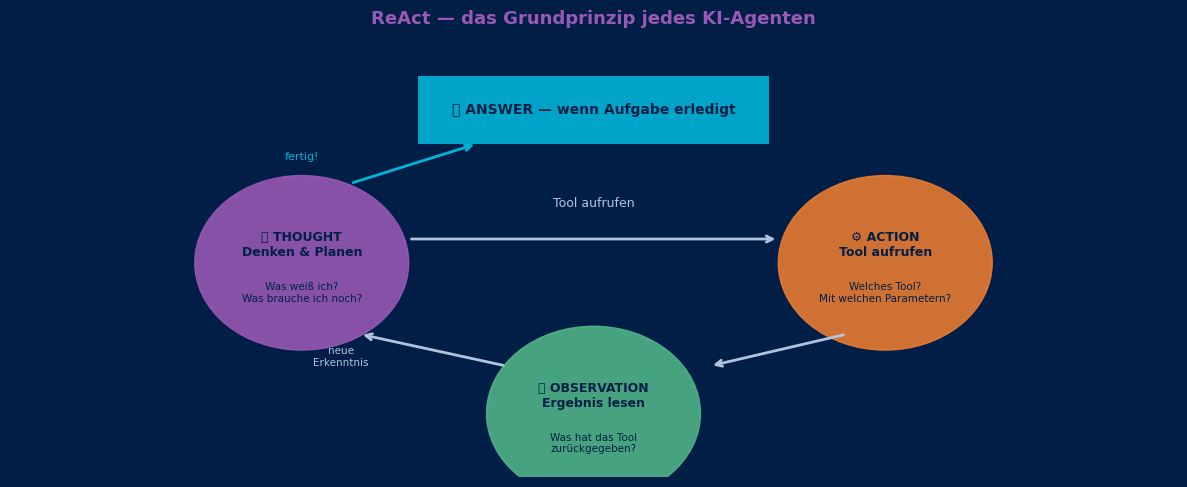

Merksatz:
  Agent = LLM (Denken) + Tools (Handeln) + Schleife (ReAct)

In Schritt 1 haben wir die Schleife manuell geschrieben.
In Schritt 3 übernimmt eine Python-Klasse das automatisch.
In Schritt 5 übernimmt ein echtes LLM das Denken.


In [4]:
# ════════════════════════════════════════════════════════════
# ReAct-Schleife als Diagramm
# ════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(C['navy'])
ax.set_xlim(0,12); ax.set_ylim(0,5.5); ax.axis('off')
ax.set_facecolor(C['navy'])
ax.set_title('ReAct — das Grundprinzip jedes KI-Agenten',
             color=C['purple'], fontsize=13, fontweight='bold', pad=12)

# Drei Knoten
for (x,y,col,lbl,sub) in [
    (3.0,2.7,C['purple'],"💭 THOUGHT\nDenken & Planen",    "Was weiß ich?\nWas brauche ich noch?"),
    (9.0,2.7,C['orange'],"⚙️ ACTION\nTool aufrufen",       "Welches Tool?\nMit welchen Parametern?"),
    (6.0,0.8,C['green'], "👁️ OBSERVATION\nErgebnis lesen", "Was hat das Tool\nzurückgegeben?"),
]:
    ax.add_patch(plt.Circle((x,y),1.1,color=col,alpha=0.88,zorder=3))
    ax.text(x,y+0.22,lbl,ha='center',va='center',fontsize=9,fontweight='bold',
            color=C['navy'],multialignment='center',zorder=4)
    ax.text(x,y-0.38,sub,ha='center',va='center',fontsize=7.5,
            color=C['navy'],multialignment='center',zorder=4)

# Pfeile
p = dict(arrowstyle='->',lw=2.0)
ax.annotate('',xy=(7.9,3.0),xytext=(4.1,3.0),arrowprops={**p,'color':C['lgray']})
ax.text(6.0,3.4,'Tool aufrufen',ha='center',fontsize=9,color=C['lgray'])
ax.annotate('',xy=(7.2,1.4),xytext=(8.6,1.8),arrowprops={**p,'color':C['lgray']})
ax.annotate('',xy=(3.6,1.8),xytext=(5.1,1.4),arrowprops={**p,'color':C['lgray']})
ax.text(3.4,1.4,'neue\nErkenntnis',ha='center',fontsize=7.5,color=C['lgray'])

# Answer
ax.add_patch(plt.Rectangle((4.2,4.2),3.6,0.85,
             facecolor=C['teal'],edgecolor='none',alpha=0.9,zorder=3))
ax.text(6.0,4.63,'✅ ANSWER — wenn Aufgabe erledigt',
        ha='center',va='center',fontsize=10,fontweight='bold',color=C['navy'],zorder=4)
ax.annotate('',xy=(4.8,4.2),xytext=(3.5,3.7),arrowprops={**p,'color':C['teal']})
ax.text(3.0,4.0,'fertig!',ha='center',fontsize=8,color=C['teal'])

plt.tight_layout(); plt.show()

print("Merksatz:")
print("  Agent = LLM (Denken) + Tools (Handeln) + Schleife (ReAct)")
print()
print("In Schritt 1 haben wir die Schleife manuell geschrieben.")
print("In Schritt 3 übernimmt eine Python-Klasse das automatisch.")
print("In Schritt 5 übernimmt ein echtes LLM das Denken.")


---

## 🔧 Schritt 2 — Tools: Der Werkzeugkasten des Agenten

### Was ist ein Tool?

Ein **Tool** ist eine Python-Funktion die ein Agent gezielt aufrufen kann.
Ohne Tools kennt das LLM nur sein Training — keine aktuellen Akten, keine Berechnung,
keine Datenbankabfrage. Tools sind die Verbindung zur realen Welt.

Der `@tool`-Dekorator (das `@` vor `def`) registriert eine Funktion als Tool.
LangChain liest den **Docstring** — die Beschreibung direkt unter `def` —
und nutzt ihn um zu entscheiden wann das Tool aufgerufen wird.

```python
@tool
def pruefe_iban(iban: str) -> str:
    """Überprüft das Format einer deutschen IBAN..."""   # ← LLM liest das
    ...
```

> 💡 Ein präziser Docstring = bessere Entscheidungen des Agenten.
> Vage Beschreibungen führen zu falschen Tool-Aufrufen.

### Unsere vier Tools für AZ 2026-KK-00471

| Tool | Was es tut | Datenquelle |
|------|-----------|-------------|
| `suche_akte` | Durchsucht die Ermittlungsakte | GitHub: alle JSON-Dateien |
| `pruefe_iban` | Validiert IBAN-Format + Datenbankabgleich | GitHub: konten.json |
| `berechne` | Mathematische Berechnungen | lokal (sicherer eval) |
| `bewerte_risiko` | Risikostufe aus Personen-/Org-Datenbasis | GitHub: personen.json, baltic_trade.json |


In [5]:
# ════════════════════════════════════════════════════════════
# SCHRITT 2 — Vier LangChain-Tools für die Fallanalyse
#
# Jedes Tool greift auf die echte GitHub-Datenbasis zu.
# Der @tool-Dekorator macht es für LangChain-Agenten nutzbar.
# ════════════════════════════════════════════════════════════

@tool
def suche_akte(suchbegriff: str) -> str:
    """
    Durchsucht die Ermittlungsakte AZ 2026-KK-00471.
    Verfügbare Kategorien — genau diese Begriffe verwenden:
      'sachverhalt'  → Tatbeschreibung, Tatmodus, Überblick
      'transaktion'  → Beide Überweisungen mit Datum, Betrag, SWIFT-Referenz
      'iban'         → IBAN-Details, Kontoinhaber, Sperrstatus
      'deepfake'     → Forensischer Video-Befund, KI-Wahrscheinlichkeit
      'tatbestand'   → Anwendbare Paragraphen mit Begründung
      'massnahmen'   → Laufende Ermittlungsmaßnahmen (TKÜ, Sperre, Rechtshilfe)
      'timeline'     → Chronologischer Ablauf aller Ereignisse
      'zeuge'        → Aussagen von Frau Auer und Herrn Maier
      'bondarenko'   → Angaben zum Tatverdächtigen TV2
    Immer einfache Schlüsselwörter verwenden, keine ganzen Sätze.
    """
    s = suchbegriff.lower()
    out = []

    # Sachverhalt und Tatmodus
    if any(x in s for x in ['sachverhalt','tatmodus','fall','überblick']) and fallakte:
        sf = fallakte['sachverhalt']
        out.append(f"[SACHVERHALT] {sf['kurzfassung']}")
        out.append(f"[TATMODUS] {sf['tatmodus']} | Schaden: {sf['gesamtschaden_eur']:,.0f} EUR")

    # Transaktionen
    if any(x in s for x in ['transaktion','überweisung','swift']) and transaktionen:
        for t in transaktionen['transaktionen']:
            out.append(
                f"[{t['id']}] {t['datum']} {t['uhrzeit']} | {t['betrag_eur']:,.0f} EUR | "
                f"{t['auftraggeber']['name']} → {t['empfaenger']['name']} | "
                f"Ref: {t['swift_ref']} | Status: {t['status']}")

    # IBAN / Konto
    if any(x in s for x in ['iban','konto','bank']) and konten:
        for k in konten['konten']:
            out.append(
                f"[KONTO {k['id']}] {k['iban']} | {k['inhaber']} | "
                f"{k['bank']} | Risiko: {k['risikostufe']} | "
                f"Status: {k['konto_status']} | "
                f"Eröffnet: {k.get('konto_eroeffnet','?')}")

    # Deepfake-Befund
    if any(x in s for x in ['deepfake','video','ki-generiert']) and deepfake:
        a = deepfake['analyse']
        out.append(
            f"[DEEPFAKE] {a['ki_wahrscheinlichkeit_prozent']}% KI-Wahrscheinlichkeit | "
            f"{a['tool']} {a['version']} | Befund: {a['befund']} | "
            f"Gutachter: {a['analyst']}")
        out.append("[DEEPFAKE-METHODEN] " + " | ".join(
            f"{m['methode'][:35]} (Score: {m['score']})"
            for m in a.get('methoden',[])))

    # Tatbestände
    if any(x in s for x in ['tatbestand','paragraph','stgb','delikt']) and fallakte:
        out.append("[TATBESTÄNDE] " + " | ".join(
            f"{t['paragraph']} {t['bezeichnung']}: {t['begruendung'][:70]}"
            for t in fallakte['tatbestaende']))

    # Maßnahmen
    if any(x in s for x in ['massnahmen','massnahme','tku','sperre','rechtshilfe']) and fallakte:
        out.append("[MASSNAHMEN] " + " | ".join(
            f"{m['massnahme']} → {m.get('ziel', m.get('betrag_eur','-'))} ({m['status']}, {m['datum']})"
            for m in fallakte.get('massnahmen',[])))

    # Timeline
    if any(x in s for x in ['timeline','zeitlinie','chronologie','ablauf']) and timeline:
        out.append("[TIMELINE] " + " → ".join(
            f"{e['datum']} {e['ereignis']}"
            for e in timeline['timeline']))

    # Zeugenaussagen
    if any(x in s for x in ['zeuge','auer','maier','vernehmung']) and vernehmungen:
        for v in vernehmungen['vernehmungen']:
            out.append(
                f"[{v['id']}] {v['zeuge_name']} ({v['datum']}): "
                f"{v['protokoll_auszug'][:150]}...")

    # Tatverdächtiger Bondarenko
    if any(x in s for x in ['bondarenko','tv2','tatverd']) and personen:
        tv2 = next((p for p in personen['personen'] if p.get('kuerzel')=='TV2'), None)
        if tv2:
            out.append(
                f"[TV2] {tv2['vorname']} {tv2['nachname']} | "
                f"geb. {tv2['geburtsdatum']} | {tv2['staatsangehoerigkeit']} | "
                f"Funktion: {tv2['funktion']} | Risiko: {tv2['risikostufe']} | "
                f"Maßnahmen: {', '.join(tv2['massnahmen'])}")

    if out:
        return "\n".join(out)
    return (f"Kein Eintrag für '{suchbegriff}'. "
            "Verfügbare Begriffe: sachverhalt, transaktion, iban, deepfake, "
            "tatbestand, massnahmen, timeline, zeuge, bondarenko")


@tool
def pruefe_iban(iban: str) -> str:
    """
    Überprüft das Format einer deutschen IBAN und gleicht sie mit der
    Ermittlungs-Datenbasis ab. Gibt Formatprüfung + Kontoinhaber + Risikostufe zurück.
    Benutze dieses Tool für jede IBAN aus der Akte.
    """
    iban_clean = iban.replace(' ','').upper()

    # Format-Prüfung
    if not iban_clean.startswith('DE'):
        return f"❌ Kein DE-IBAN (Prefix fehlt): {iban}"
    if len(iban_clean) != 22:
        return f"❌ Falsche Länge: {len(iban_clean)} Stellen (DE-IBAN = 22)"

    pruefz = int(iban_clean[2:4])
    fmt = ' '.join(iban_clean[i:i+4] for i in range(0,22,4))
    result = [f"✅ Format gültig: {fmt}",
              f"   Land: Deutschland | Prüfziffern: {pruefz}"]

    # Datenbankabgleich
    if konten:
        for k in konten['konten']:
            if iban_clean in k['iban'].replace(' ',''):
                result += [
                    f"   ┌─ Datenbasis-Treffer ───────────────────────────",
                    f"   │  Inhaber:      {k['inhaber']}",
                    f"   │  Bank:         {k['bank']}",
                    f"   │  Eröffnet:     {k.get('konto_eroeffnet','?')}",
                    f"   │  Status:       {k['konto_status']}",
                    f"   │  Risiko:       {k['risikostufe']}",
                    f"   └────────────────────────────────────────────────"]
                if k['auffaelligkeiten']:
                    result.append("   Auffälligkeiten:")
                    for a in k['auffaelligkeiten'][:3]:
                        result.append(f"     • {a}")
    return "\n".join(result)


@tool
def berechne(ausdruck: str) -> str:
    """
    Berechnet einen mathematischen Ausdruck (+ - * /).
    Für Schadensberechnungen, Zinsen oder Währungsumrechnungen.
    Beispiele: '93400 + 28750', '122150 * 1.19', '93400 / 122150 * 100'
    """
    # Sicherheitscheck: nur Zahlen und Operatoren erlaubt
    if not all(c in '0123456789+-*/.() ' for c in ausdruck):
        return "❌ Nur Zahlen und +-*/() erlaubt (Sicherheitsfilter)"
    try:
        ergebnis = eval(ausdruck)  # noqa: S307
        return f"✅ {ausdruck} = {ergebnis:,.2f}"
    except Exception as e:
        return f"❌ Fehler: {e}"


@tool
def bewerte_risiko(name: str) -> str:
    """
    Bewertet das Risiko einer Person oder Organisation.
    Sucht in der Personen-Datenbasis (Tatverdächtige, Zeugen) und
    in der Organisations-Datenbasis (Baltic Trade LLC).
    Gibt Risikostufe, Rolle und bekannte Verbindungen zurück.
    """
    suche = name.lower()
    out = []

    # Personen-Datenbasis
    if personen:
        for p in personen['personen']:
            vollname = f"{p.get('vorname','')} {p['nachname']}".lower()
            if any(w in suche for w in vollname.split() if len(w)>2):
                out.append(
                    f"[PERSON] {p.get('vorname','')} {p['nachname']} | "
                    f"Rolle: {p['rolle']} | Risiko: {p['risikostufe']}")
                if p.get('massnahmen'):
                    out.append(f"  Maßnahmen: {', '.join(p['massnahmen'])}")

    # Organisations-Datenbasis
    if baltic_trade:
        org = baltic_trade['organisation']
        if any(w in suche for w in ['baltic','trade']):
            out += [
                f"[ORGANISATION] {org['name']} | Risiko: {org['risikostufe']}",
                f"  Sitz:         {org['sitz']}",
                f"  Gegründet:    {org['eintragungsdatum']}",
                f"  Gesellschaft: {org['gesellschafter'][0]['name']} (100%)"]
            out.append("  Auffälligkeiten:")
            for a in org['auffaelligkeiten'][:4]:
                out.append(f"    • {a}")

    return "\n".join(out) if out else f"'{name}' nicht in Datenbasis — unbekannt"


# ── Demonstration ─────────────────────────────────────────────
print("VIER TOOLS — DIREKTE AUFRUFE MIT ECHTER DATENBASIS")
print("=" * 60)

print("\n1. pruefe_iban('DE89 3704 0044 0532 0130 00')")
print(pruefe_iban.invoke({'iban': 'DE89 3704 0044 0532 0130 00'}))

print("\n2. berechne('93400 + 28750')")
print(berechne.invoke({'ausdruck': '93400 + 28750'}))

print("\n3. bewerte_risiko('Baltic Trade LLC')")
print(bewerte_risiko.invoke({'name': 'Baltic Trade LLC'}))

print("\n4. suche_akte('sachverhalt')")
print(suche_akte.invoke({'suchbegriff': 'sachverhalt'}))


VIER TOOLS — DIREKTE AUFRUFE MIT ECHTER DATENBASIS

1. pruefe_iban('DE89 3704 0044 0532 0130 00')
✅ Format gültig: DE89 3704 0044 0532 0130 00
   Land: Deutschland | Prüfziffern: 89
   ┌─ Datenbasis-Treffer ───────────────────────────
   │  Inhaber:      Baltic Trade LLC
   │  Bank:         Commerzbank AG
   │  Eröffnet:     2025-11-03
   │  Status:       gesperrt (Kontensperre seit 2026-01-11)
   │  Risiko:       HOCH
   └────────────────────────────────────────────────
   Auffälligkeiten:
     • Konto erst 2 Monate vor Tatbegehung eröffnet
     • Keine reguläre Geschäftstätigkeit erkennbar
     • Soforttransfers nach Eingang der Überweisung

2. berechne('93400 + 28750')
✅ 93400 + 28750 = 122,150.00

3. bewerte_risiko('Baltic Trade LLC')
[ORGANISATION] Baltic Trade LLC | Risiko: HOCH
  Sitz:         Hamburger Allee 12, 60486 Frankfurt am Main
  Gegründet:    2025-10-15
  Gesellschaft: Maksym Bondarenko (100%)
  Auffälligkeiten:
    • Gegründet nur 3 Monate vor Tatbegehung
    • Keine 

---

## 🤖 Schritt 3 — Mini-Agent: Die ReAct-Schleife automatisiert

### Was ist neu gegenüber Schritt 1?

In Schritt 1 haben wir jeden Schritt **manuell** aufgeschrieben.
Hier baut die `MiniAgent`-Klasse die Schleife **automatisch** auf —
wir übergeben nur die Aufgabe, der Agent erledigt den Rest.

### Was ist eine Klasse?

Eine `class` ist eine Vorlage für Objekte. Wie ein Formular:
- `__init__()` füllt das Formular aus (erstellt den Agenten)
- `run()` startet die Analyse
- `_denke()` entscheidet was als nächstes zu tun ist

**Wichtig:** Das Reasoning in `_denke()` ist hier noch **regelbasiert** —
wir haben einen festen Plan aufgeschrieben. In Schritt 5 ersetzt ein LLM
diese Funktion und entscheidet frei.


In [6]:
# ════════════════════════════════════════════════════════════
# SCHRITT 3 — MiniAgent: automatische ReAct-Schleife
#
# _denke() = regelbasierter Plan (if/elif)
# In Schritt 5 → ersetzt durch echtes LLM-Reasoning
# ════════════════════════════════════════════════════════════

class MiniAgent:
    """
    Forensischer Ermittlungs-Agent mit automatischer ReAct-Schleife.

    Aufbau:
      __init__()       → Erstellt Agenten, registriert Tools
      run(aufgabe)     → Startet die Analyse-Schleife
      _denke(...)      → Entscheidet: welches Tool als nächstes?
      _tool_aufrufen() → Führt ein Tool aus, gibt Ergebnis zurück
    """

    def __init__(self, name: str = "Ermittlungs-Agent"):
        self.name      = name
        self.max_steps = 10
        self.verlauf   = []   # Alle Schritte werden protokolliert
        # Werkzeugkasten: Name → LangChain-Tool-Objekt
        self.tools = {
            'suche_akte':     suche_akte,
            'pruefe_iban':    pruefe_iban,
            'berechne':       berechne,
            'bewerte_risiko': bewerte_risiko,
        }

    def _tool_aufrufen(self, tool_name: str, argumente: dict) -> str:
        """Ruft ein Tool auf und gibt das Ergebnis zurück.
        LangChain-Tools werden über .invoke(dict) aufgerufen."""
        if tool_name not in self.tools:
            return f"⚠️ Tool '{tool_name}' nicht vorhanden"
        try:
            return str(self.tools[tool_name].invoke(argumente))
        except Exception as e:
            return f"⚠️ Fehler: {e}"

    def _denke(self, ergebnisse: list) -> dict:
        """
        Regelbasiertes Reasoning — in Schritt 5 durch LLM ersetzt.
        Gibt zurück:
          {'typ':'aktion', 'tool':..., 'args':..., 'gedanke':...}
          {'typ':'antwort', 'antwort':..., 'gedanke':...}
        """
        schritt = len(ergebnisse)

        # Fester Plan: 6 Schritte, dann Antwort
        plan = [
            {'tool': 'suche_akte',
             'args': {'suchbegriff': 'sachverhalt'},
             'gedanke': 'Erst Überblick verschaffen: Sachverhalt abrufen.'},
            {'tool': 'suche_akte',
             'args': {'suchbegriff': 'transaktion'},
             'gedanke': 'Transaktionsdaten aus der Akte laden.'},
            {'tool': 'pruefe_iban',
             'args': {'iban': 'DE89 3704 0044 0532 0130 00'},
             'gedanke': 'Empfänger-IBAN validieren und Datenbasis abgleichen.'},
            {'tool': 'bewerte_risiko',
             'args': {'name': 'Baltic Trade LLC'},
             'gedanke': 'Risikostufe des Empfängers prüfen.'},
            {'tool': 'berechne',
             'args': {'ausdruck': '93400 + 28750'},
             'gedanke': 'Gesamtschaden aus beiden Transaktionen berechnen.'},
            {'tool': 'suche_akte',
             'args': {'suchbegriff': 'tatbestand'},
             'gedanke': 'Rechtliche Tatbestände für den Abschlussbefund abrufen.'},
        ]

        if schritt < len(plan):
            return {'typ': 'aktion', **plan[schritt]}

        # Alle Daten gesammelt → Antwort aus echter Datenbasis
        schaden = f"{fallakte['sachverhalt']['gesamtschaden_eur']:,.0f} EUR" if fallakte else "122.150 EUR"
        tbs = " + ".join(t['paragraph'] for t in fallakte.get('tatbestaende',[])) if fallakte else "§263+§269+§263a"
        return {
            'typ': 'antwort',
            'gedanke': 'Alle Informationen aus der Datenbasis gesammelt. Befund formulieren.',
            'antwort': (
                f"━━━ FORENSISCHER BEFUND AZ 2026-KK-00471 ━━━\n"
                f"  Gesamtschaden:   {schaden} (zwei Überweisungen Jan 2026)\n"
                f"  Empfänger:       Baltic Trade LLC → HOCHRISIKO\n"
                f"  IBAN:            DE89 3704 0044 0532 0130 00 → gesperrt\n"
                f"  Tatverdächtiger: Bondarenko Maksym, Ukraine (TV2)\n"
                f"  Deepfake-Befund: 97,4% KI-Wahrscheinlichkeit (FaceForensics++ v3.1)\n"
                f"  Tatbestände:     {tbs}\n"
                f"  Empfehlung:      Kontensperre + Haftbefehl + EU-Rechtshilfe Ukraine"
            )
        }

    def run(self, aufgabe: str) -> str:
        """Startet die ReAct-Schleife und gibt den Abschlussbefund zurück."""
        print(f"🤖 {self.name}")
        print(f"📋 Aufgabe: {aufgabe}")
        print("=" * 65)
        ergebnisse = []

        for nr in range(self.max_steps):
            entsch = self._denke(ergebnisse)
            print(f"\n[Schritt {nr+1}]")
            print(f"  💭 Thought:  {entsch['gedanke']}")

            if entsch['typ'] == 'aktion':
                tname = entsch['tool']
                targs = entsch['args']
                print(f"  ⚙️  Action:   {tname}({targs})")
                ergebnis = self._tool_aufrufen(tname, targs)
                ergebnisse.append(ergebnis)
                # Erste Zeile des Ergebnisses zeigen
                erste_zeile = ergebnis.split('\n')[0]
                print(f"  👁️  Ergebnis: {erste_zeile[:100]}")
                self.verlauf.append({'schritt':nr+1,'tool':tname,'ergebnis':ergebnis})

            elif entsch['typ'] == 'antwort':
                print(f"\n{'━'*65}")
                print(entsch['antwort'])
                return entsch['antwort']

        return "⚠️ Maximale Schrittzahl erreicht"

# ── Agent starten ─────────────────────────────────────────────
agent = MiniAgent("Ermittlungs-Agent v1.0 (regelbasiert)")
agent.run("Analysiere Akte AZ 2026-KK-00471 vollständig und erstelle einen Befund.")


🤖 Ermittlungs-Agent v1.0 (regelbasiert)
📋 Aufgabe: Analysiere Akte AZ 2026-KK-00471 vollständig und erstelle einen Befund.

[Schritt 1]
  💭 Thought:  Erst Überblick verschaffen: Sachverhalt abrufen.
  ⚙️  Action:   suche_akte({'suchbegriff': 'sachverhalt'})
  👁️  Ergebnis: [SACHVERHALT] CEO-Fraud mittels KI-generiertem Deepfake-Video-Call. Tatverdächtiger täuschte Buchhal

[Schritt 2]
  💭 Thought:  Transaktionsdaten aus der Akte laden.
  ⚙️  Action:   suche_akte({'suchbegriff': 'transaktion'})
  👁️  Ergebnis: [T001] 2026-01-09 14:32:07 | 93,400 EUR | DataTrust GmbH → Baltic Trade LLC | Ref: SWIFT-2026-01-09-

[Schritt 3]
  💭 Thought:  Empfänger-IBAN validieren und Datenbasis abgleichen.
  ⚙️  Action:   pruefe_iban({'iban': 'DE89 3704 0044 0532 0130 00'})
  👁️  Ergebnis: ✅ Format gültig: DE89 3704 0044 0532 0130 00

[Schritt 4]
  💭 Thought:  Risikostufe des Empfängers prüfen.
  ⚙️  Action:   bewerte_risiko({'name': 'Baltic Trade LLC'})
  👁️  Ergebnis: [ORGANISATION] Baltic Trade LLC | R

'━━━ FORENSISCHER BEFUND AZ 2026-KK-00471 ━━━\n  Gesamtschaden:   122,150 EUR (zwei Überweisungen Jan 2026)\n  Empfänger:       Baltic Trade LLC → HOCHRISIKO\n  IBAN:            DE89 3704 0044 0532 0130 00 → gesperrt\n  Tatverdächtiger: Bondarenko Maksym, Ukraine (TV2)\n  Deepfake-Befund: 97,4% KI-Wahrscheinlichkeit (FaceForensics++ v3.1)\n  Tatbestände:     § 263 StGB + § 269 StGB + § 263a StGB\n  Empfehlung:      Kontensperre + Haftbefehl + EU-Rechtshilfe Ukraine'

---

## 👥 Schritt 4 — Multi-Agent: Arbeitsteilung wie in der echten Ermittlung

### Warum mehrere Agenten?

In der Realität arbeiten Ermittlungen arbeitsteilig:
das Forensik-Labor analysiert Beweise,
die Staatsanwaltschaft ordnet rechtlich ein,
der Sachbearbeiter schreibt den Bericht.

Genauso kann man KI-Agenten spezialisieren.
Jeder Agent bekommt einen Teilauftrag und gibt seine Ergebnisse
als **Kontext** an den nächsten weiter — das nennt sich **Handoff**.

```
Koordinator
    │
    ├─▶ Tech-Agent     liest deepfake.json + beweismittel.json
    │       └─ Ergebnis (forensischer Befund) ──────────────┐
    │                                                        ▼
    ├─▶ Legal-Agent    liest tatbestaende.json + Kontext Tech
    │       └─ Ergebnis (Tatbestände, Zuständigkeit) ───────┐
    │                                                        ▼
    └─▶ Report-Agent   fasst alles zusammen → Kurzbericht
```

### Was ist neu gegenüber Schritt 3?

In Schritt 3 hatte ein einzelner Agent einen festen Plan.
Hier haben **drei Agenten** je einen eigenen Fokus — und jeder
kennt die Ergebnisse seines Vorgängers.


In [7]:
# ════════════════════════════════════════════════════════════
# SCHRITT 4 — Multi-Agent Handoff mit echter Datenbasis
#
# Drei spezialisierte Agenten arbeiten nacheinander.
# Jeder übergibt seine Ergebnisse an den nächsten (Handoff).
# ════════════════════════════════════════════════════════════

class ForensikAgent:
    """
    Technischer Forensik-Agent.
    Liest deepfake_befund.json und beweismittel.json aus der Datenbasis.
    """
    name = "Tech-Agent (Forensik-Labor)"

    def analysiere(self) -> dict:
        print(f"\n  ┌─── {self.name}")
        print(f"  │ Aufgabe: Deepfake-Befund + Beweismittel-Übersicht")

        ergebnis = {}

        # Aus echter deepfake.json
        if deepfake:
            a = deepfake['analyse']
            ergebnis['deepfake_wahrscheinlichkeit'] = a['ki_wahrscheinlichkeit_prozent']
            ergebnis['deepfake_befund']  = a['befund']
            ergebnis['deepfake_tool']    = f"{a['tool']} {a['version']}"
            ergebnis['deepfake_analyst'] = a['analyst']
            ergebnis['deepfake_hash']    = deepfake['hash_sha256']
            ergebnis['deepfake_einschraenkung'] = a['einschraenkungen'][:80]

        # Aus echter beweismittel.json
        if beweismittel:
            bms = beweismittel['beweismittel']
            ergebnis['anzahl_beweismittel'] = len(bms)
            ergebnis['beweiskette'] = beweismittel['beweiskette_gesamt']
            ergebnis['beweismittel_liste'] = [
                f"{b['id']}: {b['bezeichnung'][:45]} (SHA256: {b['hash_sha256'][:12]}...)"
                for b in bms]

        for k, v in ergebnis.items():
            if isinstance(v, list):
                print(f"  │ {k}:")
                for item in v: print(f"  │   • {item}")
            else:
                print(f"  │ {k}: {str(v)[:75]}")
        print(f"  └─── {self.name}: fertig")
        return ergebnis


class LegalAgent:
    """
    Rechtlicher Einordnungs-Agent.
    Liest tatbestaende.json und ergänzt den Tech-Kontext.
    """
    name = "Legal-Agent (Staatsanwaltschaft)"

    def analysiere(self, tech_kontext: dict) -> dict:
        print(f"\n  ┌─── {self.name}")
        print(f"  │ Aufgabe: Rechtliche Einordnung | Kontext: {list(tech_kontext.keys())[:3]}...")

        ergebnis = {}

        # Aus echter tatbestaende.json
        if recht:
            rf = recht['rechtlicher_rahmen']
            # Strafrecht
            straf = rf.get('strafrecht', [])
            ergebnis['tatbestaende'] = [
                f"{t['paragraph']} {t['bezeichnung']}"
                for t in straf if t.get('anwendbar') is True]
            ergebnis['tatbestand_begruendungen'] = {
                t['paragraph']: t['begruendung'][:80]
                for t in straf if t.get('anwendbar') is True}
            # EU-Rechtshilfe
            eu = rf.get('eu_rechtshilfe', {})
            ergebnis['eu_rechtshilfe'] = (
                f"{eu.get('zielland','')} | beantragt: {eu.get('beantragt','')} | "
                f"Bearbeitungszeit: {eu.get('bearbeitungszeit_erfahrungswert','?')}")
            # Forensische Anforderungen
            ergebnis['gericht_anforderungen'] = rf.get('forensische_anforderungen_gericht', [])

        # Tech-Kontext übernehmen
        deepfake_pct = tech_kontext.get('deepfake_wahrscheinlichkeit', 0)
        ergebnis['zustaendigkeit']   = "Staatsanwaltschaft Stuttgart, Ref. Cybercrime"
        ergebnis['konfidenz_aussage'] = (
            f"Mit {deepfake_pct}% Wahrscheinlichkeit KI-generiertes Video — "
            f"Sachverständigen-Gutachten für Hauptverhandlung erforderlich.")

        for k, v in ergebnis.items():
            if isinstance(v, list):
                print(f"  │ {k}:")
                for item in v[:3]: print(f"  │   • {item}")
            elif isinstance(v, dict):
                print(f"  │ {k}: {list(v.keys())}")
            else:
                print(f"  │ {k}: {str(v)[:75]}")
        print(f"  └─── {self.name}: fertig")
        return ergebnis


class ReportAgent:
    """
    Berichts-Agent.
    Fasst Tech- und Legal-Ergebnisse zu einem Kurzbericht zusammen.
    """
    name = "Report-Agent (Sachbearbeiter KK5)"

    def erstelle_bericht(self, tech: dict, legal: dict) -> str:
        print(f"\n  ┌─── {self.name}")
        print(f"  │ Aufgabe: Ermittlungs-Kurzbericht erstellen")

        # Echte Daten aus fallakte.json für den Bericht
        az     = fallakte.get('aktenzeichen','AZ 2026-KK-00471') if fallakte else 'AZ 2026-KK-00471'
        schaden = f"{fallakte['sachverhalt']['gesamtschaden_eur']:,.0f} EUR" if fallakte else "122.150 EUR"
        status = fallakte.get('status','laufend') if fallakte else 'laufend'

        from datetime import datetime
        now = datetime.now().strftime('%d.%m.%Y %H:%M')

        tbs = " · ".join(legal.get('tatbestaende', []))
        massnahmen = " · ".join(
            f"{m['massnahme']} ({m['status']})"
            for m in fallakte.get('massnahmen',[])
        ) if fallakte else "–"

        bericht = (
            f"╔══════════════════════════════════════════════════════════╗\n"
            f"║  ERMITTLUNGS-KURZBERICHT (Multi-Agent, automatisch)      ║\n"
            f"╠══════════════════════════════════════════════════════════╣\n"
            f"║  AZ:         {az:<45}║\n"
            f"║  Erstellt:   {now:<45}║\n"
            f"║  Status:     {status:<45}║\n"
            f"╠══════════════════════════════════════════════════════════╣\n"
            f"║  SCHADEN:    {schaden:<45}║\n"
            f"║  TATMITTEL:  Deepfake-Video {tech.get('deepfake_wahrscheinlichkeit',0)}%"
            f"{'':>{45-len(f'Deepfake-Video {tech.get(chr(100)+chr(101)+chr(101)+chr(112)+chr(102)+chr(97)+chr(107)+chr(101)+chr(95)+chr(119)+chr(97)+chr(104)+chr(114)+chr(115)+chr(99)+chr(104)+chr(101)+chr(105)+chr(110)+chr(108)+chr(105)+chr(99)+chr(104)+chr(107)+chr(101)+chr(105)+chr(116),0)}%')}}║\n"
            f"╠══════════════════════════════════════════════════════════╣\n"
            f"║  TATBESTÄNDE: {tbs[:43]:<43}║\n"
            f"║  MASSNAHMEN:  {massnahmen[:43]:<43}║\n"
            f"╠══════════════════════════════════════════════════════════╣\n"
            f"║  BEWEISMITTEL: {tech.get('anzahl_beweismittel',0)} gesichert"
            f" | Kette: {tech.get('beweiskette','?'):<22}║\n"
            f"╠══════════════════════════════════════════════════════════╣\n"
            f"║  ⚠️  Automatisch erstellt — fachliche Prüfung erforderlich ║\n"
            f"╚══════════════════════════════════════════════════════════╝"
        )

        print(f"  └─── {self.name}: fertig")
        return bericht


# ── Workflow ausführen ────────────────────────────────────────
print("MULTI-AGENT WORKFLOW — AZ 2026-KK-00471")
print("=" * 65)
print("[Koordinator] Starte Analyse mit drei spezialisierten Agenten...")

tech_agent   = ForensikAgent()
legal_agent  = LegalAgent()
report_agent = ReportAgent()

# Handoff-Kette
tech_ergebnis  = tech_agent.analysiere()
legal_ergebnis = legal_agent.analysiere(tech_ergebnis)
bericht        = report_agent.erstelle_bericht(tech_ergebnis, legal_ergebnis)

print("\n" + "=" * 65)
print("[Koordinator] Abschlussbericht:")
print()
print(bericht)


MULTI-AGENT WORKFLOW — AZ 2026-KK-00471
[Koordinator] Starte Analyse mit drei spezialisierten Agenten...

  ┌─── Tech-Agent (Forensik-Labor)
  │ Aufgabe: Deepfake-Befund + Beweismittel-Übersicht
  │ deepfake_wahrscheinlichkeit: 97.4
  │ deepfake_befund: HOCHWAHRSCHEINLICH KI-GENERIERT
  │ deepfake_tool: FaceForensics++ v3.1
  │ deepfake_analyst: Sachverständiger Dr. A. Weber, LKA BW
  │ deepfake_hash: a3f9d1c8e7b2f5d4c9a1e6b3f8d2c7a4e5b1f9d3c6a2e8b4f7d1c5a3e9b2f6d8
  │ deepfake_einschraenkung: Keine absolute Gewissheit möglich. Konfidenz-Aussage: 'Mit 97,4% Wahrschein
  │ anzahl_beweismittel: 5
  │ beweiskette: vollständig
  │ beweismittel_liste:
  │   • BM-001: E-Mail datatrust-gmbh.de vom 03.01.2026 (SHA256: b7e3f1a9d5c2...)
  │   • BM-002: E-Mail datatrust-gmbh.de vom 05.01.2026 mit Ü (SHA256: c4f8e2a6d1b5...)
  │   • BM-003: Teams-Aufzeichnung Deepfake-Video-Call 07.01. (SHA256: a3f9d1c8e7b2...)
  │   • BM-004: Kontoauszug DataTrust GmbH Jan 2026 (Transakt (SHA256: d5a9e3c7f1b4...)

---

## 🔗 Schritt 5 — Echter LLM-Agent mit LangChain + LangGraph

### Was ist der Unterschied zu Schritt 3?

| | Schritt 3 MiniAgent | Schritt 5 LangChain-Agent |
|---|---|---|
| **Reasoning** | Regelbasiert — fester Plan | LLM entscheidet frei |
| **Tool-Auswahl** | `if schritt == 0:` | LLM wählt selbst |
| **Antwort** | Hartcodierter Text | LLM formuliert in natürlicher Sprache |
| **Reihenfolge** | Immer gleich | Variiert je nach Aufgabe |

### Wie funktioniert `create_react_agent()`?

LangGraph baut die gesamte ReAct-Schleife automatisch auf.
Wir übergeben nur:
- **`llm`** — das Sprachmodell (aus Zelle A)
- **`tools`** — unsere vier Werkzeuge (aus Schritt 2)

Das LLM entscheidet dann selbst: welches Tool wann aufrufen,
wie die Ergebnisse interpretieren, wann die Aufgabe erledigt ist.

> Der LLM-Provider (`llm`) wurde in **Zelle A** festgelegt.
> Falls kein LLM verbunden ist, läuft dieser Schritt mit
> dem Ergebnis aus Schritt 3 — kein Absturz.


In [8]:
# ════════════════════════════════════════════════════════════
# SCHRITT 5 — Echter LLM-Agent: LangChain + LangGraph
#
# llm und llm_aktiv wurden in Zelle A gesetzt.
# Die Tools wurden in Schritt 2 definiert.
# Hier werden beide kombiniert.
# ════════════════════════════════════════════════════════════

print(f"LLM-Provider: {llm_name}")
print()

if llm_aktiv:
    # ── Echten Agenten aufbauen ───────────────────────────────
    # create_react_agent() von LangGraph übernimmt die gesamte
    # ReAct-Schleife. Wir liefern nur LLM + Tools.
    agent_tools = [suche_akte, pruefe_iban, berechne, bewerte_risiko]
    react_agent = create_react_agent(llm, agent_tools)

    # System-Anweisung: Kontext und verfügbare Suchbegriffe
    system = (
        "Du bist ein forensischer Ermittlungsassistent der Polizei Baden-Württemberg. "
        "Du hast Zugriff auf die Ermittlungsakte AZ 2026-KK-00471 (CEO-Fraud, Deepfake). "
        "Verfügbare Suchbegriffe für suche_akte(): sachverhalt, transaktion, iban, "
        "deepfake, tatbestand, massnahmen, timeline, zeuge, bondarenko. "
        "Nutze genau diese Begriffe. Antworte immer auf Deutsch. "
        "Sei präzise, forensisch korrekt und zitiere Fundstellen aus der Akte."
    )

    aufgabe = (
        "Analysiere den Fall AZ 2026-KK-00471 systematisch:\n"
        "1. Verschaffe dir einen Überblick über den Sachverhalt\n"
        "2. Prüfe die IBAN DE89 3704 0044 0532 0130 00\n"
        "3. Bewerte das Risiko von Baltic Trade LLC\n"
        "4. Berechne den Gesamtschaden (93400 + 28750 EUR)\n"
        "5. Hole den Deepfake-Befund ab\n"
        "6. Hole die anwendbaren Tatbestände\n"
        "7. Fasse alles als strukturierten forensischen Kurzbericht zusammen"
    )

    print(f"Aufgabe (gekürzt): {aufgabe.splitlines()[0]}...")
    print("─" * 65)
    print()

    ergebnis = react_agent.invoke({
        "messages": [
            SystemMessage(content=system),
            HumanMessage(content=aufgabe),
        ]
    })

    # Protokoll der Tool-Aufrufe
    print("PROTOKOLL — Tool-Aufrufe des LLM:")
    print("─" * 65)
    for msg in ergebnis["messages"]:
        if isinstance(msg, AIMessage):
            for aufruf in (getattr(msg,'tool_calls',None) or []):
                print(f"  ⚙️  {aufruf['name']}({aufruf['args']})")
        if isinstance(msg, ToolMessage):
            erste = str(msg.content).split('\n')[0][:90]
            print(f"  👁️  → {erste}")

    # Finale Antwort
    print()
    print("ANTWORT DES LLM:")
    print("─" * 65)
    for msg in ergebnis["messages"]:
        if isinstance(msg, AIMessage) and msg.content:
            print(msg.content)

else:
    # ── Kein LLM: Ergebnis aus Schritt 3 zeigen ──────────────
    print("ℹ️  Kein LLM aktiv.")
    print("   Das Ergebnis aus Schritt 3 (regelbasierter Agent) steht oben.")
    print()
    print("Was ein echtes LLM anders macht:")
    print()
    print("  Regelbasiert (Schritt 3):")
    print("    _denke() → fester Plan, immer gleiche Reihenfolge,")
    print("    Antwort ist hartcodierter String")
    print()
    print("  Echtes LLM (Schritt 5):")
    print("    Das Modell liest Aufgabe + bisherige Ergebnisse")
    print("    und entscheidet selbst: welches Tool jetzt sinnvoll ist,")
    print("    ob die Informationen reichen, wie die Antwort formuliert wird.")
    print("    Die Reihenfolge kann variieren, die Antwort ist natürliche Sprache.")
    print()
    print("  Zum Aktivieren:")
    print("    • Seminarraum: Ollama starten → ollama pull llama3.1:8b")
    print("    • Colab/lokal: Groq-Key in Zelle A eingeben")


LLM-Provider: Groq API (llama-3.1-8b-instant)

Aufgabe (gekürzt): Analysiere den Fall AZ 2026-KK-00471 systematisch:...
─────────────────────────────────────────────────────────────────

PROTOKOLL — Tool-Aufrufe des LLM:
─────────────────────────────────────────────────────────────────
  ⚙️  suche_akte({'suchbegriff': 'sachverhalt'})
  ⚙️  suche_akte({'suchbegriff': 'transaktion'})
  ⚙️  pruefe_iban({'iban': 'DE89 3704 0044 0532 0130 00'})
  ⚙️  bewerte_risiko({'name': 'Baltic Trade LLC'})
  ⚙️  berechne({'ausdruck': '93400 + 28750'})
  ⚙️  suche_akte({'suchbegriff': 'deepfake'})
  ⚙️  suche_akte({'suchbegriff': 'tatbestand'})
  ⚙️  suche_akte({'suchbegriff': 'massnahmen'})
  ⚙️  suche_akte({'suchbegriff': 'timeline'})
  ⚙️  suche_akte({'suchbegriff': 'zeuge'})
  ⚙️  suche_akte({'suchbegriff': 'bondarenko'})
  ⚙️  suche_akte({'suchbegriff': 'sachverhalt'})
  👁️  → [SACHVERHALT] CEO-Fraud mittels KI-generiertem Deepfake-Video-Call. Tatverdächtiger täusch
  👁️  → [T001] 2026-01-09 14:32:

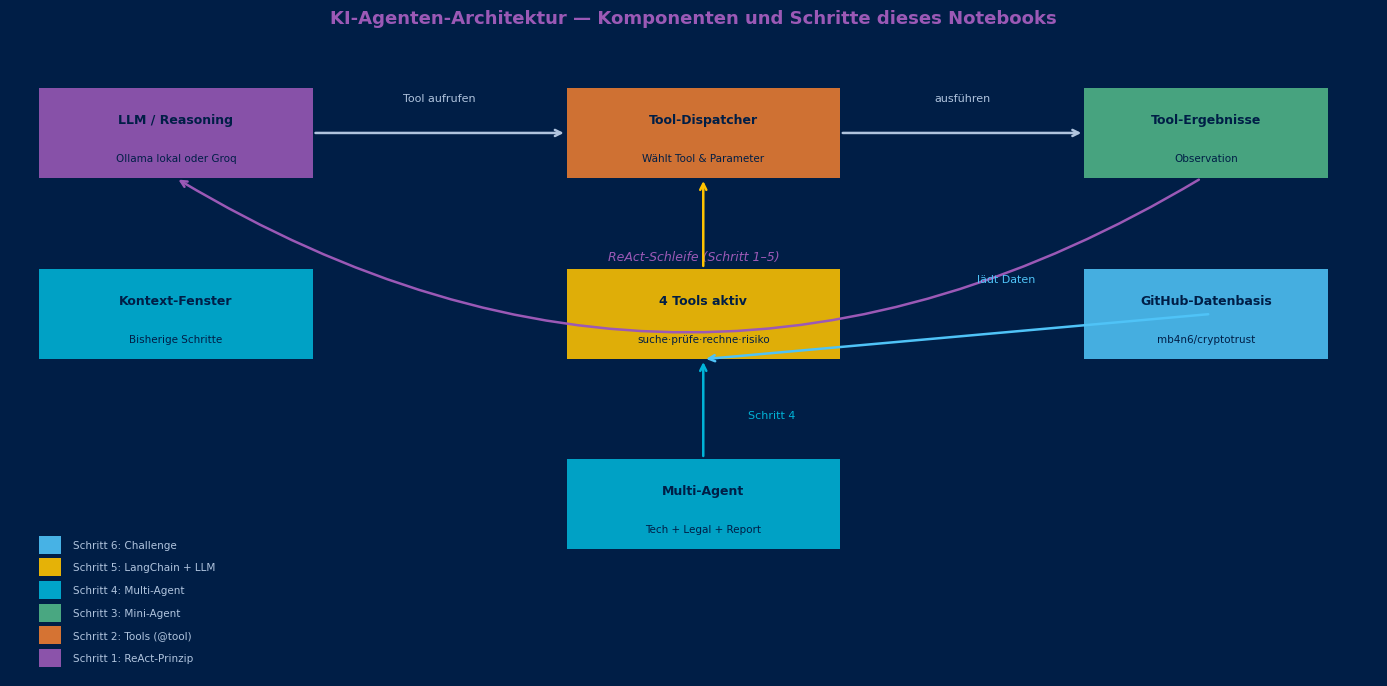

In [9]:
# ════════════════════════════════════════════════════════════
# Architektur-Überblick: Alle Komponenten dieses Notebooks
# ════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(C['navy'])
ax.set_xlim(0,14); ax.set_ylim(0,7); ax.axis('off')
ax.set_facecolor(C['navy'])
ax.set_title('KI-Agenten-Architektur — Komponenten und Schritte dieses Notebooks',
             color=C['purple'], fontsize=13, fontweight='bold', pad=14)

komp = [
    # (x, y, w, h, farbe, titel, untertitel)
    (0.3,5.5,2.8,1.0,C['purple'],'LLM / Reasoning', 'Ollama lokal oder Groq'),
    (5.7,5.5,2.8,1.0,C['orange'],'Tool-Dispatcher',  'Wählt Tool & Parameter'),
    (11.0,5.5,2.5,1.0,C['green'],'Tool-Ergebnisse',  'Observation'),
    (0.3,3.5,2.8,1.0,C['teal'],  'Kontext-Fenster',  'Bisherige Schritte'),
    (5.7,3.5,2.8,1.0,C['gold'],  '4 Tools aktiv',    'suche·prüfe·rechne·risiko'),
    (11.0,3.5,2.5,1.0,C['ice'],  'GitHub-Datenbasis','mb4n6/cryptotrust'),
    (5.7,1.4,2.8,1.0,C['teal'],  'Multi-Agent',      'Tech + Legal + Report'),
]
for x,y,w,h,col,t,s in komp:
    ax.add_patch(plt.Rectangle((x,y),w,h,facecolor=col,edgecolor='none',alpha=0.88))
    ax.text(x+w/2,y+h*0.65,t,ha='center',va='center',fontsize=9,
            fontweight='bold',color=C['navy'],multialignment='center')
    ax.text(x+w/2,y+h*0.22,s,ha='center',va='center',fontsize=7.5,
            color=C['navy'],multialignment='center')

p = dict(arrowstyle='->',lw=1.8)
ax.annotate('',xy=(5.7,6.0),xytext=(3.1,6.0),arrowprops={**p,'color':C['lgray']})
ax.text(4.4,6.35,'Tool aufrufen',ha='center',fontsize=8,color=C['lgray'])
ax.annotate('',xy=(11.0,6.0),xytext=(8.5,6.0),arrowprops={**p,'color':C['lgray']})
ax.text(9.75,6.35,'ausführen',ha='center',fontsize=8,color=C['lgray'])
ax.annotate('',xy=(1.7,5.5),xytext=(12.2,5.5),
            arrowprops={**p,'color':C['purple'],'connectionstyle':'arc3,rad=-0.3'})
ax.text(7.0,4.6,'ReAct-Schleife (Schritt 1–5)',ha='center',fontsize=9,
        color=C['purple'],style='italic')
ax.annotate('',xy=(7.1,5.5),xytext=(7.1,4.5),arrowprops={**p,'color':C['gold']})
ax.annotate('',xy=(7.1,3.5),xytext=(12.3,4.0),arrowprops={**p,'color':C['ice']})
ax.text(10.2,4.35,'lädt Daten',ha='center',fontsize=8,color=C['ice'])
ax.annotate('',xy=(7.1,3.5),xytext=(7.1,2.4),arrowprops={**p,'color':C['teal']})
ax.text(7.8,2.85,'Schritt 4',ha='center',fontsize=8,color=C['teal'])

# Legende
legende = [
    (C['purple'],'Schritt 1: ReAct-Prinzip'),
    (C['orange'],'Schritt 2: Tools (@tool)'),
    (C['green'], 'Schritt 3: Mini-Agent'),
    (C['teal'],  'Schritt 4: Multi-Agent'),
    (C['gold'],  'Schritt 5: LangChain + LLM'),
    (C['ice'],   'Schritt 6: Challenge'),
]
for i,(col,lbl) in enumerate(legende):
    ax.add_patch(plt.Rectangle((0.3,0.1+i*0.25),0.22,0.2,facecolor=col,alpha=0.9))
    ax.text(0.65,0.2+i*0.25,lbl,va='center',fontsize=7.5,color=C['lgray'])

plt.tight_layout(); plt.show()


---

## 📋 Zusammenfassung

### Was haben Sie in diesem Notebook gelernt?

| Schritt | Konzept | Was konkret passiert ist |
|---------|---------|--------------------------|
| 1 | **ReAct-Prinzip** | Thought → Action → Observation manuell an der echten Akte ausgeführt |
| 2 | **Tools** | Vier `@tool`-Funktionen mit direktem Zugriff auf GitHub-Datenbasis |
| 3 | **Mini-Agent** | ReAct-Klasse mit 6-Schritt-Plan, vollständige Fallanalyse automatisch |
| 4 | **Multi-Agent** | Tech/Legal/Report-Agent mit Handoff, Daten aus deepfake.json + tatbestaende.json |
| 5 | **Echter LLM-Agent** | `create_react_agent()` — LLM entscheidet frei über Tool-Auswahl und Formulierung |

---

### Die drei Kernaussagen

> **1. Agent = LLM + Tools + Schleife.**
> Das LLM denkt. Tools handeln. Die Schleife verbindet beides.

---

### Agenten - Workflows

> Grog Cloud: https://console.groq.com/home

> Langchain: https://www.langchain.com/

> n8n: https://n8n.io

> uipath: https://www.uipath.com/platform/agentic-automation

> ai sworm: https://github.com/ai-swarm-dev/ai-swarm

> crew ai: https://crewai.com/

> zapier: https://zapier.com/

> autogen: https://github.com/microsoft/autogen

---

**KI Advanced · IA1017000 · Polizei Baden-Württemberg · Institut für Fortbildung**
*Stand: März 2026 · Marc Brandt · HfPolBW*
